In [34]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [35]:

# Set random seeds for reproducibility
np.random.seed(42)

In [36]:
df = pd.read_csv('df_hands_final.csv')

In [37]:
def get_pair(row):
    if row['two_pair']:
        return 2
    elif row['one_pair']:
        return 1
    else:
        return 0

df['pair'] = df.apply(get_pair, axis=1)

# Now drop the original 'one_pair' and 'two_pair' columns
df.drop(columns=['one_pair', 'two_pair'], inplace=True)

df.drop(columns=['straight', 'flush'], inplace=True)


def combine_straight_risk(row):
    if row['major_straight_risk']:
        return 2
    elif row['straight_risk']:
        return 1
    else:
        return 0

df['straight_risk_combined'] = df.apply(combine_straight_risk, axis=1)

def combine_flush_risk(row):
    if row['major_flush_risk']:
        return 2
    elif row['flush_risk']:
        return 1
    else:
        return 0

df['flush_risk_combined'] = df.apply(combine_flush_risk, axis=1)

df.drop(columns=[
    'straight_risk', 'major_straight_risk',
    'flush_risk', 'major_flush_risk',
], inplace=True)



In [38]:
df

,Unnamed: 0,id,handType,player_type,position,street,decision_time,action,PIP,betRatio,tofk,ace_high,pair,straight_risk_combined,flush_risk_combined
0,0,171926864524501,bluff,villain,IP,preflop,15.495,raises_to,5,1.500,False,False,0,0,0
1,1,171926864524501,bluff,hero,OOP,preflop,29.401,calls,2,0.300,False,False,0,0,0
2,2,171926864524501,bluff,hero,OOP,flop,1.413,checks,2,0.000,False,False,1,0,0
3,3,171926864524501,bluff,villain,IP,flop,12.443,bets,2,0.308,False,False,1,0,0
4,4,171926864524501,bluff,hero,OOP,flop,1.163,calls,2,0.235,False,False,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32299,51446,174099297249500,value,villain,IP,flop,1.419,calls,2,0.250,False,True,0,0,0
32300,51447,174099297249500,value,hero,OOP,turn,1.381,checks,2,0.000,False,True,0,1,0
32301,51448,174099297249500,value,villain,IP,turn,1.783,checks,2,0.000,False,True,0,1,0
32302,51449,174099297249500,value,hero,OOP,river,0.838,checks,2,0.000,False,True,0,1,0


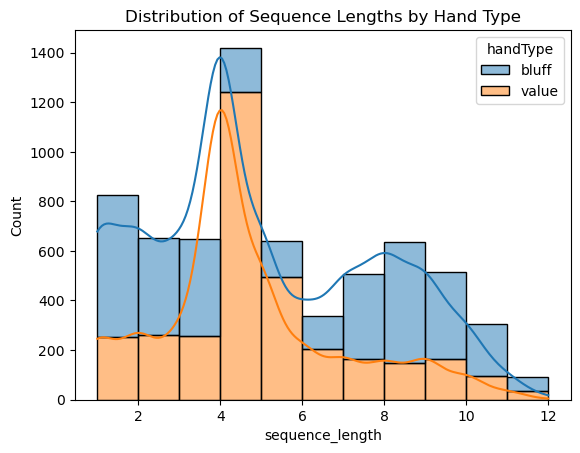

In [39]:
df_lengths = df.groupby(['handType', 'id']).size().reset_index(name='sequence_length')

# 2. Plot the distribution of sequence_length for each handType
# Option A: single histogram with color/hue by handType
sns.histplot(data=df_lengths, x='sequence_length', hue='handType', kde=True, multiple='stack', binwidth=1)
plt.title('Distribution of Sequence Lengths by Hand Type')
plt.show()

In [40]:
number_of_hands = df['id'].nunique()
number_of_hands

6568

Using device: cpu
DataFrame shape: (32304, 15)
   Unnamed: 0               id handType player_type position   street  \
0           0  171926864524501    bluff     villain       IP  preflop   
1           1  171926864524501    bluff        hero      OOP  preflop   
2           2  171926864524501    bluff        hero      OOP     flop   
3           3  171926864524501    bluff     villain       IP     flop   
4           4  171926864524501    bluff        hero      OOP     flop   

   decision_time     action  PIP  betRatio   tofk  ace_high  pair  \
0         15.495  raises_to    5     1.500  False     False     0   
1         29.401      calls    2     0.300  False     False     0   
2          1.413     checks    2     0.000  False     False     1   
3         12.443       bets    2     0.308  False     False     1   
4          1.163      calls    2     0.235  False     False     1   

   straight_risk_combined  flush_risk_combined  
0                       0                    0  
1

/Users/cynthiadu/anaconda3/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "
/var/folders/dp/p5h_rmqs29qbz18zl9tszqx40000gn/T/ipykernel_45012/91309524.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  seq_lengths_tensor = torch.tensor(seq_lengths, device=output.device) - 1  # adjust for 0-indexing


Epoch 1/50, Batch 10/132, Loss: 0.5658
Epoch 1/50, Batch 20/132, Loss: 0.5087
Epoch 1/50, Batch 30/132, Loss: 0.6218
Epoch 1/50, Batch 40/132, Loss: 0.3319
Epoch 1/50, Batch 50/132, Loss: 0.3287
Epoch 1/50, Batch 60/132, Loss: 0.4743
Epoch 1/50, Batch 70/132, Loss: 0.4245
Epoch 1/50, Batch 80/132, Loss: 0.4123
Epoch 1/50, Batch 90/132, Loss: 0.4860
Epoch 1/50, Batch 100/132, Loss: 0.6091
Epoch 1/50, Batch 110/132, Loss: 0.4317
Epoch 1/50, Batch 120/132, Loss: 0.4509
Epoch 1/50, Batch 130/132, Loss: 0.4158
Epoch 1/50 | Train Loss: 0.5024 | Train Acc: 0.7599 | Val Loss: 0.4495 | Val Acc: 0.7964
New best validation accuracy: 0.7964, model saved
Epoch 2/50, Batch 10/132, Loss: 0.4229
Epoch 2/50, Batch 20/132, Loss: 0.7103
Epoch 2/50, Batch 30/132, Loss: 0.3245
Epoch 2/50, Batch 40/132, Loss: 0.4453
Epoch 2/50, Batch 50/132, Loss: 0.4523
Epoch 2/50, Batch 60/132, Loss: 0.3839
Epoch 2/50, Batch 70/132, Loss: 0.4222
Epoch 2/50, Batch 80/132, Loss: 0.4051
Epoch 2/50, Batch 90/132, Loss: 0.4685

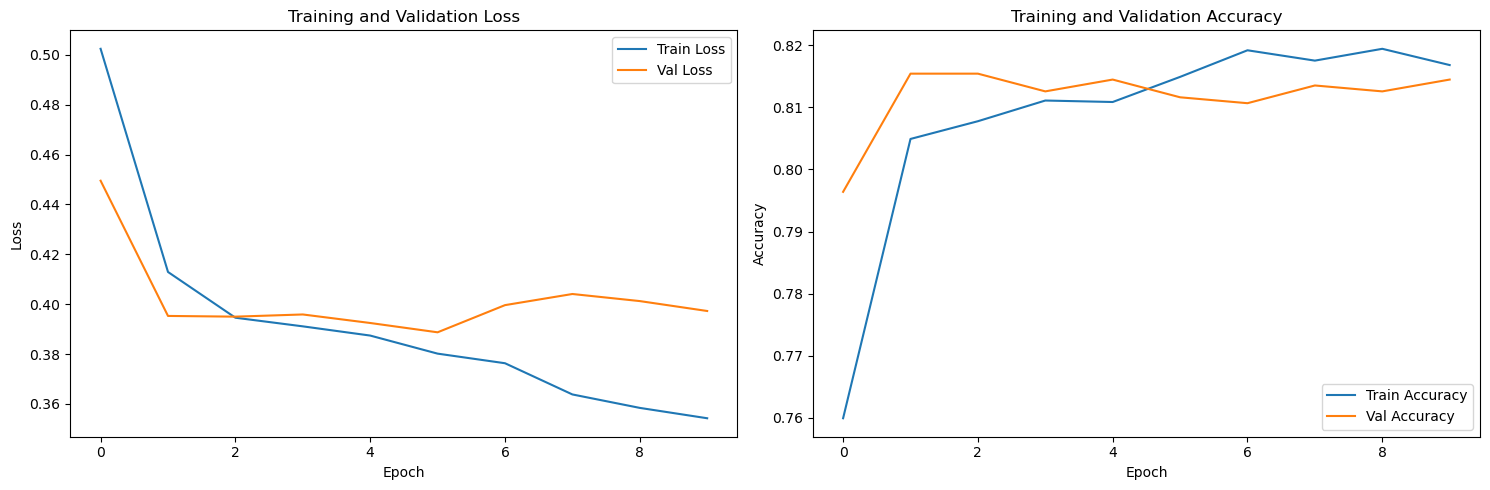


Evaluating model on test set:
Classification Report:
              precision    recall  f1-score   support

       bluff       0.75      0.97      0.85       658
       value       0.96      0.68      0.79       656

    accuracy                           0.82      1314
   macro avg       0.85      0.82      0.82      1314
weighted avg       0.85      0.82      0.82      1314



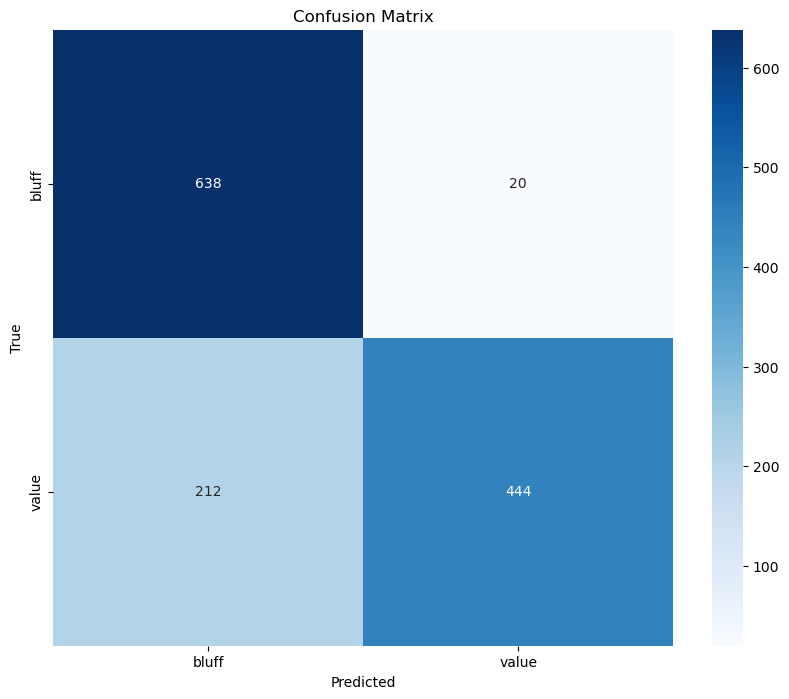

Test Accuracy: 0.8234


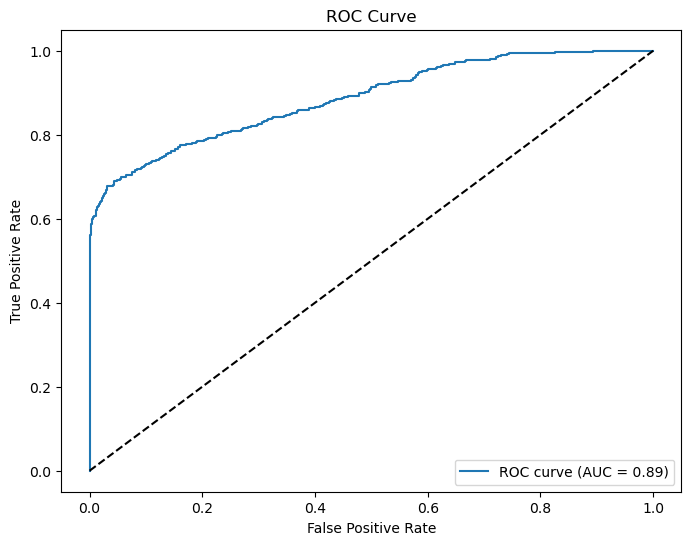

Model saved as 'poker_lstm_model_final.pth'


In [29]:
# Poker Hand Type LSTM Classifier
# This notebook implements an LSTM model to classify poker hands as "bluff" or "value"

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Assume you already have a DataFrame 'df' loaded
print("DataFrame shape:", df.shape)
print(df.head())

# Define a custom dataset class for our poker data
class PokerHandsDataset(Dataset):
    def __init__(self, sequences, labels, seq_lengths):
        self.sequences = sequences
        self.labels = labels
        self.seq_lengths = seq_lengths
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx], self.seq_lengths[idx]

# Function to preprocess the data and create sequences
def preprocess_data(df):
    # Sort by hand id and the implicit order in the dataframe
    df = df.sort_values(['id'])
    
    # Get unique hand IDs
    unique_ids = df['id'].unique()
    print(f"Total unique hands: {len(unique_ids)}")
    
    # Define categorical and numerical columns
    cat_columns = ['player_type', 'position', 'street', 'action', 'PIP']
    num_columns = ['decision_time', 'betRatio']
    bool_columns = ['tofk', 'ace_high']
    ordinal_columns = ['pair', 'straight_risk_combined', 'flush_risk_combined']
    
    # Create encoders
    cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    scaler = StandardScaler()
    
    # Fit the encoders on the entire dataset
    cat_encoder.fit(df[cat_columns])
    scaler.fit(df[num_columns])
    
    # Calculate total number of features after preprocessing
    n_cat_features = sum([len(cat_encoder.categories_[i]) for i in range(len(cat_columns))])
    n_num_features = len(num_columns)
    n_bool_features = len(bool_columns)
    n_ordinal_features = len(ordinal_columns)
    
    total_features = n_cat_features + n_num_features + n_bool_features + n_ordinal_features
    print(f"Total features after preprocessing: {total_features}")
    
    sequences = []
    seq_lengths = []
    labels = []
    
    for hand_id in unique_ids:
        hand_df = df[df['id'] == hand_id]
        
        # All rows for a hand should have the same type
        hand_type = hand_df['handType'].iloc[0]
        labels.append(0 if hand_type == 'bluff' else 1)
        seq_lengths.append(len(hand_df))
        
        # Create sequence features
        seq_features = np.zeros((len(hand_df), total_features))
        
        # Transform categorical features
        cat_transformed = cat_encoder.transform(hand_df[cat_columns])
        # Transform numerical features
        num_transformed = scaler.transform(hand_df[num_columns])
        # Convert boolean features to integers
        bool_transformed = hand_df[bool_columns].astype(int).values
        # Get ordinal features
        ordinal_transformed = hand_df[ordinal_columns].values
        
        feature_idx = 0
        seq_features[:, feature_idx:feature_idx + cat_transformed.shape[1]] = cat_transformed
        feature_idx += cat_transformed.shape[1]
        seq_features[:, feature_idx:feature_idx + num_transformed.shape[1]] = num_transformed
        feature_idx += num_transformed.shape[1]
        seq_features[:, feature_idx:feature_idx + bool_transformed.shape[1]] = bool_transformed
        feature_idx += bool_transformed.shape[1]
        seq_features[:, feature_idx:feature_idx + ordinal_transformed.shape[1]] = ordinal_transformed
        
        sequences.append(seq_features)
    
    label_counts = pd.Series(labels).value_counts()
    print(f"Label distribution: {label_counts.to_dict()}")
    
    return sequences, labels, seq_lengths, total_features

# LSTM Model for sequence classification
class PokerLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout_rate):
        super(PokerLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0,
            bidirectional=True
        )
        self.fc1 = nn.Linear(hidden_size * 2, hidden_size)  # bidirectional => *2
        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 2)  # 2 classes: bluff or value
        
    def forward(self, x, seq_lengths):
        packed_input = pack_padded_sequence(x, seq_lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, (hidden, _) = self.lstm(packed_input)
        output, _ = pad_packed_sequence(packed_output, batch_first=True)
        # output: [batch_size, max_seq_len, hidden_size*2]
        
        batch_size = output.size(0)
        seq_lengths_tensor = torch.tensor(seq_lengths, device=output.device) - 1  # adjust for 0-indexing
        batch_idx = torch.arange(batch_size, device=output.device)
        last_outputs = output[batch_idx, seq_lengths_tensor, :]  # shape: [batch_size, hidden_size*2]
        
        x = self.dropout(last_outputs)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Function to collate data for batching
def collate_fn(batch):
    sequences, labels, seq_lengths = zip(*batch)
    seq_lengths = torch.LongTensor(seq_lengths)
    seq_lengths, perm_idx = seq_lengths.sort(0, descending=True)
    sequences = [sequences[i] for i in perm_idx]
    labels = [labels[i] for i in perm_idx]
    
    max_len = seq_lengths[0].item()
    batch_size = len(sequences)
    feature_size = sequences[0].shape[1]
    padded_seqs = torch.zeros((batch_size, max_len, feature_size))
    for i, seq in enumerate(sequences):
        end = seq_lengths[i].item()
        padded_seqs[i, :end, :] = torch.FloatTensor(seq[:end])
    
    labels = torch.LongTensor(labels)
    return padded_seqs, labels, seq_lengths

# Function to train the model (with printing of training & validation accuracies)
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs):
    train_losses, val_losses = [], []
    val_accuracies, train_accuracies = [], []
    
    best_val_acc = 0.0
    patience = 8
    patience_counter = 0
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train, total_train = 0, 0
        
        for batch_idx, (inputs, labels, seq_lengths) in enumerate(train_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            seq_lengths = seq_lengths.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs, seq_lengths)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            
            if (batch_idx + 1) % 10 == 0:
                print(f'Epoch {epoch+1}/{num_epochs}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}')
        
        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        epoch_train_acc = correct_train / total_train
        train_accuracies.append(epoch_train_acc)
        
        model.eval()
        running_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels, seq_lengths in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                seq_lengths = seq_lengths.to(device)
                
                outputs = model(inputs, seq_lengths)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        epoch_val_loss = running_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        epoch_val_acc = correct / total
        val_accuracies.append(epoch_val_acc)
        
        scheduler.step(epoch_val_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | '
              f'Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}')
        
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_poker_model.pth')
            print(f"New best validation accuracy: {best_val_acc:.4f}, model saved")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping after {epoch+1} epochs')
                break

    model.load_state_dict(torch.load('best_poker_model.pth'))
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return model, train_losses, val_losses, val_accuracies

# Function to evaluate the model and plot the ROC (AUC) curve
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels, seq_lengths in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            seq_lengths = seq_lengths.to(device)
            outputs = model(inputs, seq_lengths)
            probs = nn.functional.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            # Save probability for class 1 ("value")
            all_probs.extend(probs[:, 1].cpu().numpy())
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=['bluff', 'value']))
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['bluff', 'value'], yticklabels=['bluff', 'value'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    accuracy = (all_preds == all_labels).mean()
    print(f"Test Accuracy: {accuracy:.4f}")
    
    # Compute ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()
    
    return all_preds, all_labels, accuracy

if __name__ == "__main__":
    # Preprocess the data
    sequences, labels, seq_lengths, input_size = preprocess_data(df)
    
    # Split the data into train, validation, and test sets
    X_train_val, X_test, y_train_val, y_test, len_train_val, len_test = train_test_split(
        sequences, labels, seq_lengths, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val, len_train, len_val = train_test_split(
        X_train_val, y_train_val, len_train_val, test_size=0.20, random_state=42)
    
    print(f"Training set: {len(X_train)} hands")
    print(f"Validation set: {len(X_val)} hands")
    print(f"Test set: {len(X_test)} hands")
    
    # Create datasets
    train_dataset = PokerHandsDataset(X_train, y_train, len_train)
    val_dataset = PokerHandsDataset(X_val, y_val, len_val)
    test_dataset = PokerHandsDataset(X_test, y_test, len_test)
    
    # Define hyperparameters
    batch_size = 32
    hidden_size = 128
    num_layers = 2
    dropout_rate = 0.3
    learning_rate = 0.01
    num_epochs = 50
    
    # Create data loaders (using num_workers=0)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                              collate_fn=collate_fn, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=collate_fn, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=collate_fn, num_workers=0)
    
    # Initialize model, loss, optimizer, scheduler
    model = PokerLSTM(input_size, hidden_size, num_layers, dropout_rate).to(device)
    print(model)
    print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=4, verbose=True)
    
    # Train the model
    model, train_losses, val_losses, val_accuracies = train_model(
        model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs)
    
    # Evaluate the model on the test set and plot the ROC (AUC) curve
    print("\nEvaluating model on test set:")
    all_preds, all_labels, test_accuracy = evaluate_model(model, test_loader)
    
    # Save the final model
    torch.save({
        'model_state_dict': model.state_dict(),
        'input_size': input_size,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'dropout_rate': dropout_rate,
        'test_accuracy': test_accuracy
    }, 'poker_lstm_model_final.pth')
    print("Model saved as 'poker_lstm_model_final.pth'")


In [31]:
# Timing Only Model

class TimingOnlyLSTM(nn.Module):
    def __init__(self, hidden_size, num_layers, dropout_rate):
        super(TimingOnlyLSTM, self).__init__()
        # Only use decision_time as input feature
        self.input_size = 1  
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=self.input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_size * 2, 2)
        
    def forward(self, x, seq_lengths):
        # Extract just timing information
        time_feature_idx = cat_columns_size  # Adjust based on your feature ordering
        time_features = x[:, :, time_feature_idx].unsqueeze(2)
        
        packed_input = pack_padded_sequence(time_features, seq_lengths.cpu(), 
                                           batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed_input)
        
        # Use the last hidden state from both directions
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        output = self.fc(hidden)
        return output

# Train and evaluate timing-only model
timing_model = TimingOnlyLSTM(hidden_size, num_layers, dropout_rate).to(device)
# Train with the same pipeline
# Compare with full model

### Diving More into Timing + Compare

In [44]:
def analyze_timing_importance(model, test_loader, timing_feature_idx=None):
    # If timing_feature_idx is not provided, try to get it from model if it's a TimingOnlyLSTM
    if timing_feature_idx is None:
        if hasattr(model, 'timing_feature_idx'):
            timing_feature_idx = model.timing_feature_idx
        else:
            # Default to the index that was used during preprocessing
            # This is a fallback and might need to be adjusted
            print("Warning: timing_feature_idx not provided, using global variable")
            # Use the global timing_feature_idx from preprocessing if available

    model.eval()
    original_preds = []
    shuffled_time_preds = []
    
    with torch.no_grad():
        for inputs, labels, seq_lengths in test_loader:
            inputs = inputs.to(device)
            seq_lengths = seq_lengths.to(device)
            
            # Get original predictions
            outputs = model(inputs, seq_lengths)
            _, predicted = torch.max(outputs, 1)
            original_preds.extend(predicted.cpu().numpy())
            
            # Create a copy of inputs with shuffled timing features
            shuffled_inputs = inputs.clone()
            # Use the timing feature index to get the decision_time feature
            shuffled_timing = shuffled_inputs[:, :, timing_feature_idx].clone()
            # Shuffle timing values across the batch
            indices = torch.randperm(shuffled_timing.size(0))
            shuffled_inputs[:, :, timing_feature_idx] = shuffled_timing[indices]
            
            # Get predictions with shuffled timing
            shuffled_outputs = model(shuffled_inputs, seq_lengths)
            _, shuffled_predicted = torch.max(shuffled_outputs, 1)
            shuffled_time_preds.extend(shuffled_predicted.cpu().numpy())
    
    # Convert to arrays of the same shape and type
    original_preds = np.array(original_preds)
    shuffled_time_preds = np.array(shuffled_time_preds)
    
    # Make sure both arrays have the same shape
    min_length = min(len(original_preds), len(shuffled_time_preds))
    original_preds = original_preds[:min_length]
    shuffled_time_preds = shuffled_time_preds[:min_length]
    
    # Calculate importance as the proportion of predictions that changed
    timing_importance = np.mean(original_preds != shuffled_time_preds)
    print(f"Timing feature importance: {timing_importance:.4f}")
    
    return timing_importance

Using device: cpu
DataFrame shape: (32304, 15)
   Unnamed: 0               id handType player_type position   street  \
0           0  171926864524501    bluff     villain       IP  preflop   
1           1  171926864524501    bluff        hero      OOP  preflop   
2           2  171926864524501    bluff        hero      OOP     flop   
3           3  171926864524501    bluff     villain       IP     flop   
4           4  171926864524501    bluff        hero      OOP     flop   

   decision_time     action  PIP  betRatio   tofk  ace_high  pair  \
0         15.495  raises_to    5     1.500  False     False     0   
1         29.401      calls    2     0.300  False     False     0   
2          1.413     checks    2     0.000  False     False     1   
3         12.443       bets    2     0.308  False     False     1   
4          1.163      calls    2     0.235  False     False     1   

   straight_risk_combined  flush_risk_combined  
0                       0                    0  
1

/Users/cynthiadu/anaconda3/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch 1/50, Batch 10/132, Loss: 0.6382
Epoch 1/50, Batch 20/132, Loss: 0.5616
Epoch 1/50, Batch 30/132, Loss: 0.5277
Epoch 1/50, Batch 40/132, Loss: 0.5453
Epoch 1/50, Batch 50/132, Loss: 0.2414
Epoch 1/50, Batch 60/132, Loss: 0.3991
Epoch 1/50, Batch 70/132, Loss: 0.4509
Epoch 1/50, Batch 80/132, Loss: 0.3423
Epoch 1/50, Batch 90/132, Loss: 0.3915
Epoch 1/50, Batch 100/132, Loss: 0.3166
Epoch 1/50, Batch 110/132, Loss: 0.4683
Epoch 1/50, Batch 120/132, Loss: 0.3265
Epoch 1/50, Batch 130/132, Loss: 0.3602
Epoch 1/50 | Train Loss: 0.4700 | Train Acc: 0.7752 | Val Loss: 0.4213 | Val Acc: 0.8059
New best validation accuracy: 0.8059, model saved
Epoch 2/50, Batch 10/132, Loss: 0.5297
Epoch 2/50, Batch 20/132, Loss: 0.3209
Epoch 2/50, Batch 30/132, Loss: 0.6383
Epoch 2/50, Batch 40/132, Loss: 0.4901
Epoch 2/50, Batch 50/132, Loss: 0.4308
Epoch 2/50, Batch 60/132, Loss: 0.4405
Epoch 2/50, Batch 70/132, Loss: 0.3245
Epoch 2/50, Batch 80/132, Loss: 0.2264
Epoch 2/50, Batch 90/132, Loss: 0.4441

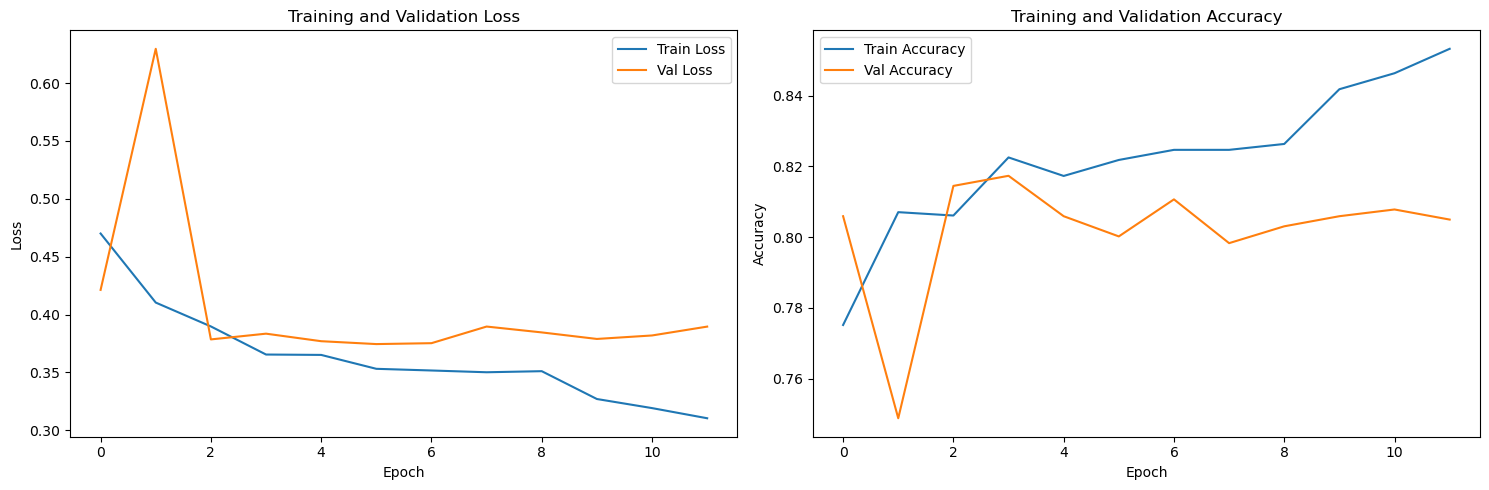


=== TRAINING TIMING-ONLY MODEL ===
Epoch 1/50, Batch 10/132, Loss: 0.6865
Epoch 1/50, Batch 20/132, Loss: 0.6634
Epoch 1/50, Batch 30/132, Loss: 0.7195
Epoch 1/50, Batch 40/132, Loss: 0.6393
Epoch 1/50, Batch 50/132, Loss: 0.6824
Epoch 1/50, Batch 60/132, Loss: 0.5022
Epoch 1/50, Batch 70/132, Loss: 0.5222
Epoch 1/50, Batch 80/132, Loss: 0.4712
Epoch 1/50, Batch 90/132, Loss: 0.6857
Epoch 1/50, Batch 100/132, Loss: 0.5928
Epoch 1/50, Batch 110/132, Loss: 0.6135
Epoch 1/50, Batch 120/132, Loss: 0.4389
Epoch 1/50, Batch 130/132, Loss: 0.5377
Epoch 1/50 | Train Loss: 0.6220 | Train Acc: 0.6633 | Val Loss: 0.5874 | Val Acc: 0.7041
New best validation accuracy: 0.7041, model saved
Epoch 2/50, Batch 10/132, Loss: 0.5536
Epoch 2/50, Batch 20/132, Loss: 0.6757
Epoch 2/50, Batch 30/132, Loss: 0.5655
Epoch 2/50, Batch 40/132, Loss: 0.6833
Epoch 2/50, Batch 50/132, Loss: 0.5623
Epoch 2/50, Batch 60/132, Loss: 0.6625
Epoch 2/50, Batch 70/132, Loss: 0.6166
Epoch 2/50, Batch 80/132, Loss: 0.5406
Ep

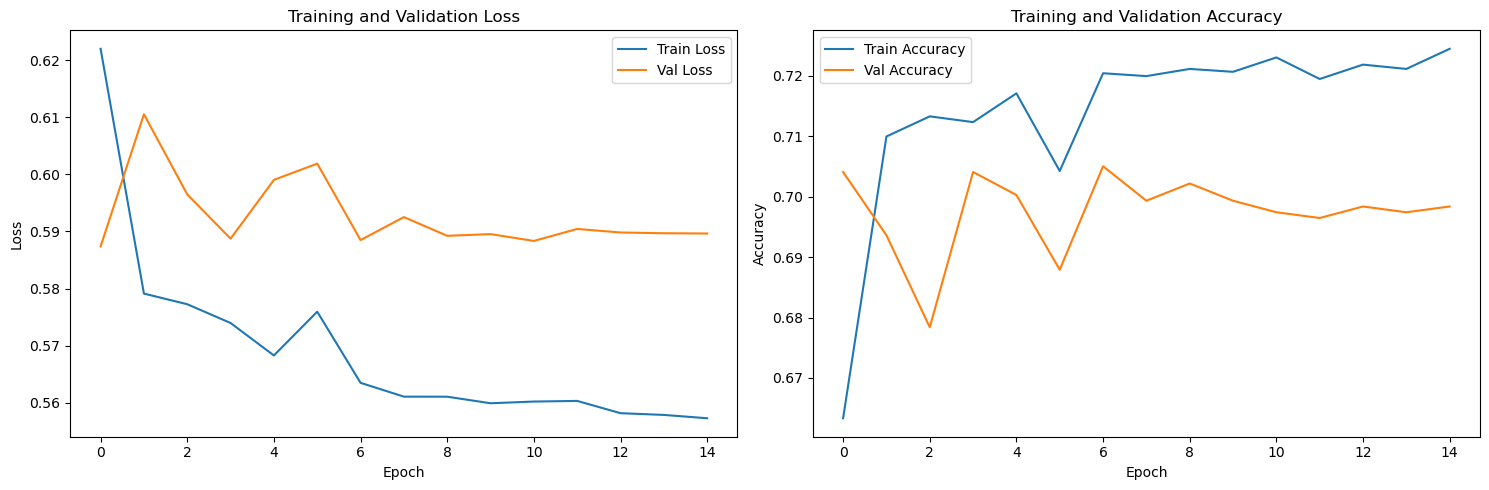


=== MODEL COMPARISON ===

Evaluating full model on test set:
Classification Report:
              precision    recall  f1-score   support

       bluff       0.76      0.92      0.83       658
       value       0.90      0.71      0.79       656

    accuracy                           0.82      1314
   macro avg       0.83      0.82      0.81      1314
weighted avg       0.83      0.82      0.81      1314



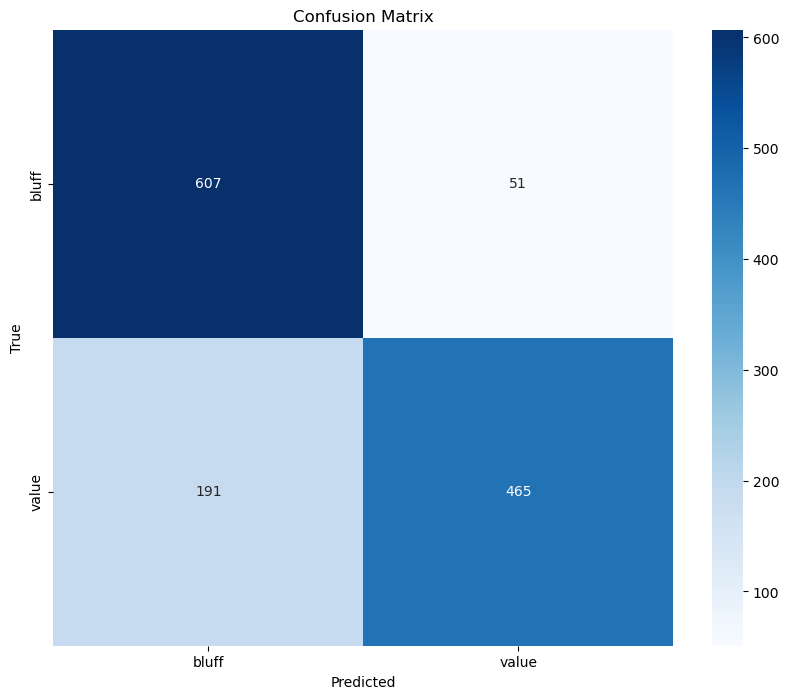

Test Accuracy: 0.8158


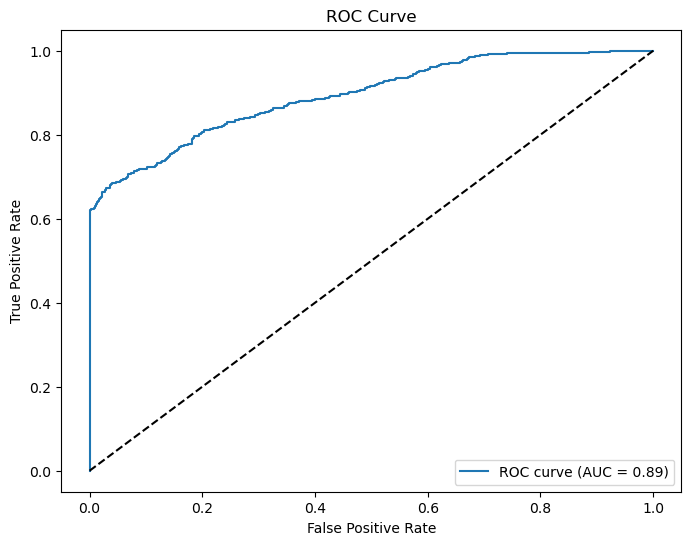


Evaluating timing-only model on test set:
Classification Report:
              precision    recall  f1-score   support

       bluff       0.69      0.87      0.77       658
       value       0.83      0.61      0.70       656

    accuracy                           0.74      1314
   macro avg       0.76      0.74      0.73      1314
weighted avg       0.76      0.74      0.73      1314



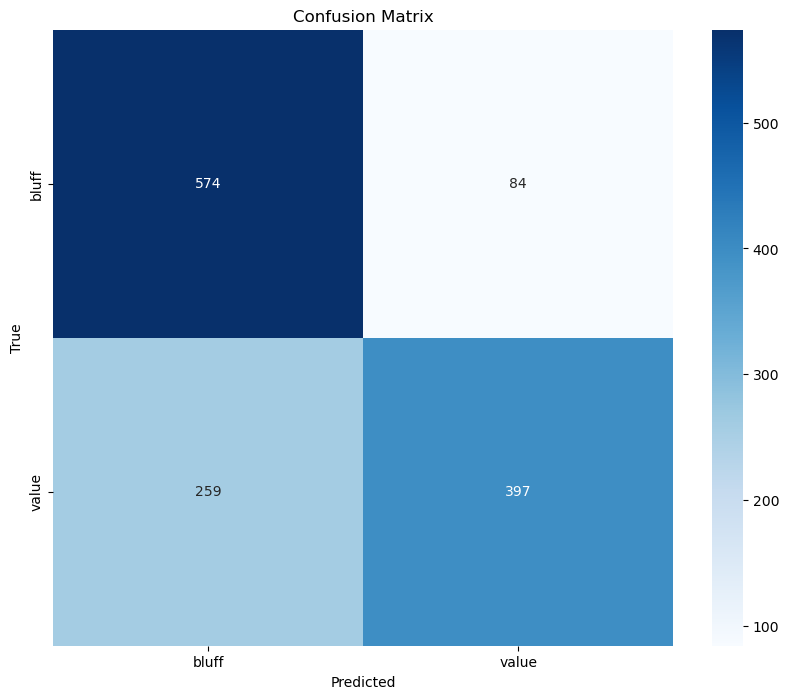

Test Accuracy: 0.7390


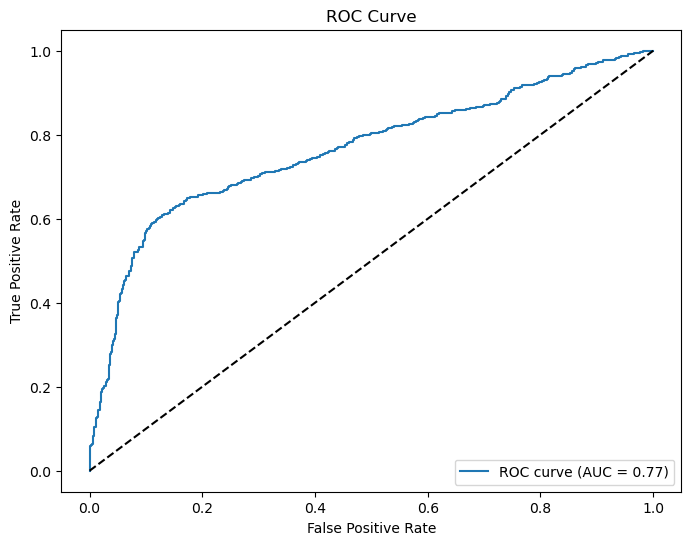


=== COMPARISON SUMMARY ===
Full model accuracy: 0.8158, AUC: 0.8929
Timing-only model accuracy: 0.7390, AUC: 0.7650

=== ANALYZING TIMING FEATURE IMPORTANCE ===
Timing feature importance: 0.0068


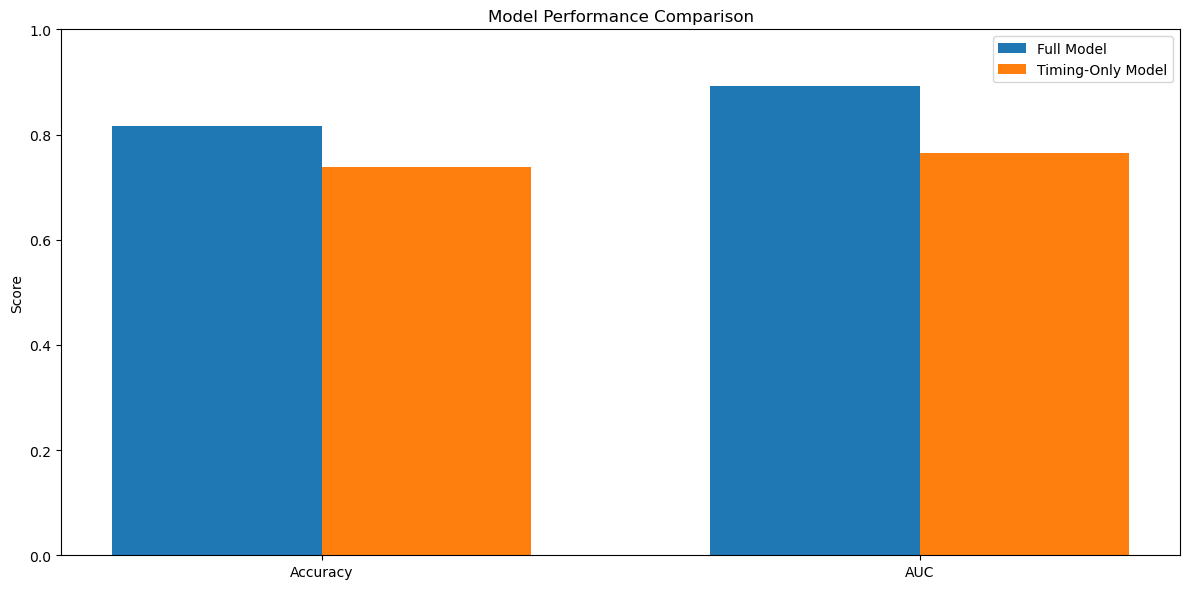


Models saved as 'poker_full_model_final.pth' and 'poker_timing_model_final.pth'


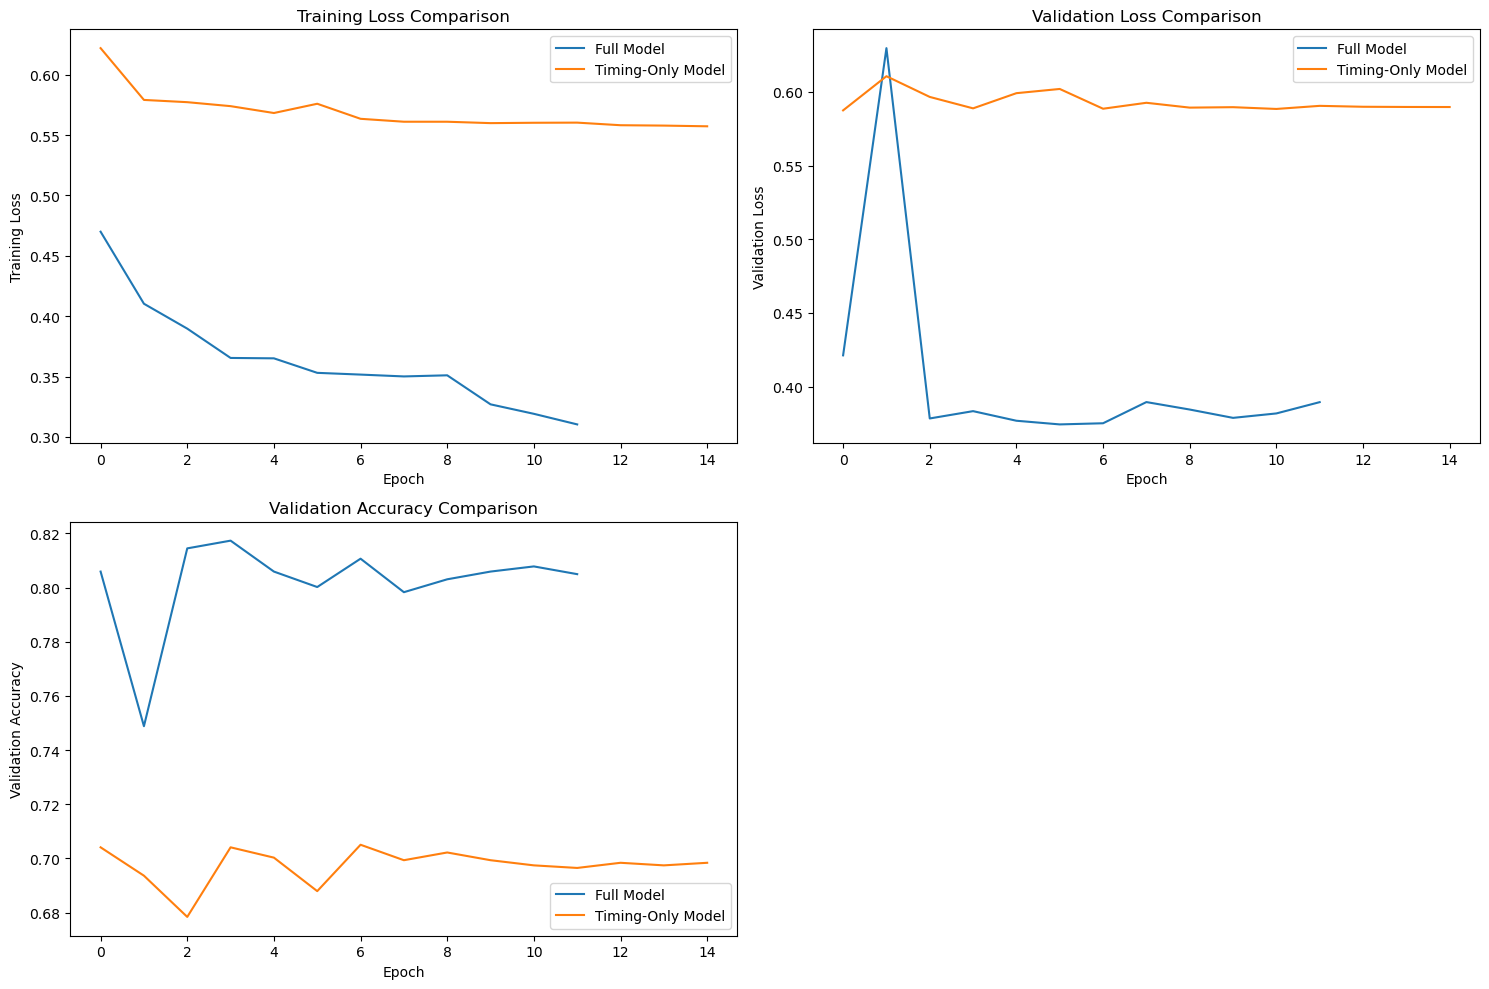

In [45]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("DataFrame shape:", df.shape)
print(df.head())

# Define a custom dataset class for our poker data
class PokerHandsDataset(Dataset):
    def __init__(self, sequences, labels, seq_lengths):
        self.sequences = sequences
        self.labels = labels
        self.seq_lengths = seq_lengths
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx], self.seq_lengths[idx]

# Base LSTM model for poker hands
class PokerLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout_rate):
        super(PokerLSTM, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_size * 2, 2)
        
    def forward(self, x, seq_lengths):
        packed_input = pack_padded_sequence(x, seq_lengths.cpu(), 
                                          batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed_input)
        
        # Use the last hidden state from both directions
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        output = self.fc(hidden)
        return output

# Timing-only LSTM model for poker bluff detection
class TimingOnlyLSTM(nn.Module):
    def __init__(self, hidden_size, num_layers, dropout_rate, timing_feature_idx):
        super(TimingOnlyLSTM, self).__init__()
        # Only use decision_time as input feature
        self.input_size = 1  
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.timing_feature_idx = timing_feature_idx
        
        self.lstm = nn.LSTM(
            input_size=self.input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_size * 2, 2)
        
    def forward(self, x, seq_lengths):
        # Extract just timing information
        time_features = x[:, :, self.timing_feature_idx].unsqueeze(2)
        
        packed_input = pack_padded_sequence(time_features, seq_lengths.cpu(), 
                                           batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed_input)
        
        # Use the last hidden state from both directions
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        output = self.fc(hidden)
        return output

# Function to preprocess the data and create sequences
def preprocess_data(df):
    # Sort by hand id and the implicit order in the dataframe
    df = df.sort_values(['id'])
    
    # Get unique hand IDs
    unique_ids = df['id'].unique()
    print(f"Total unique hands: {len(unique_ids)}")
    
    # Define categorical and numerical columns
    cat_columns = ['player_type', 'position', 'street', 'action', 'PIP']
    num_columns = ['decision_time', 'betRatio']
    bool_columns = ['tofk', 'ace_high']
    ordinal_columns = ['pair', 'straight_risk_combined', 'flush_risk_combined']
    
    # Create encoders
    cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    scaler = StandardScaler()
    
    # Fit the encoders on the entire dataset
    cat_encoder.fit(df[cat_columns])
    scaler.fit(df[num_columns])
    
    # Calculate total number of features after preprocessing
    n_cat_features = sum([len(cat_encoder.categories_[i]) for i in range(len(cat_columns))])
    n_num_features = len(num_columns)
    n_bool_features = len(bool_columns)
    n_ordinal_features = len(ordinal_columns)
    
    total_features = n_cat_features + n_num_features + n_bool_features + n_ordinal_features
    print(f"Total features after preprocessing: {total_features}")
    
    # Store indices for timing feature (decision_time)
    timing_feature_idx = n_cat_features  # Assuming decision_time is the first numerical feature
    
    sequences = []
    seq_lengths = []
    labels = []
    
    for hand_id in unique_ids:
        hand_df = df[df['id'] == hand_id]
        
        # All rows for a hand should have the same type
        hand_type = hand_df['handType'].iloc[0]
        labels.append(0 if hand_type == 'bluff' else 1)
        seq_lengths.append(len(hand_df))
        
        # Create sequence features
        seq_features = np.zeros((len(hand_df), total_features))
        
        # Transform categorical features
        cat_transformed = cat_encoder.transform(hand_df[cat_columns])
        # Transform numerical features
        num_transformed = scaler.transform(hand_df[num_columns])
        # Convert boolean features to integers
        bool_transformed = hand_df[bool_columns].astype(int).values
        # Get ordinal features
        ordinal_transformed = hand_df[ordinal_columns].values
        
        feature_idx = 0
        seq_features[:, feature_idx:feature_idx + cat_transformed.shape[1]] = cat_transformed
        feature_idx += cat_transformed.shape[1]
        seq_features[:, feature_idx:feature_idx + num_transformed.shape[1]] = num_transformed
        feature_idx += num_transformed.shape[1]
        seq_features[:, feature_idx:feature_idx + bool_transformed.shape[1]] = bool_transformed
        feature_idx += bool_transformed.shape[1]
        seq_features[:, feature_idx:feature_idx + ordinal_transformed.shape[1]] = ordinal_transformed
        
        sequences.append(seq_features)
    
    label_counts = pd.Series(labels).value_counts()
    print(f"Label distribution: {label_counts.to_dict()}")
    
    return sequences, labels, seq_lengths, total_features, timing_feature_idx

# Function to collate data for batching
def collate_fn(batch):
    sequences, labels, seq_lengths = zip(*batch)
    seq_lengths = torch.LongTensor(seq_lengths)
    seq_lengths, perm_idx = seq_lengths.sort(0, descending=True)
    sequences = [sequences[i] for i in perm_idx]
    labels = [labels[i] for i in perm_idx]
    
    max_len = seq_lengths[0].item()
    batch_size = len(sequences)
    feature_size = sequences[0].shape[1]
    padded_seqs = torch.zeros((batch_size, max_len, feature_size))
    for i, seq in enumerate(sequences):
        end = seq_lengths[i].item()
        padded_seqs[i, :end, :] = torch.FloatTensor(seq[:end])
    
    labels = torch.LongTensor(labels)
    return padded_seqs, labels, seq_lengths

# Function to train the model (with printing of training & validation accuracies)
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs):
    train_losses, val_losses = [], []
    val_accuracies, train_accuracies = [], []
    
    best_val_acc = 0.0
    patience = 8
    patience_counter = 0
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train, total_train = 0, 0
        
        for batch_idx, (inputs, labels, seq_lengths) in enumerate(train_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            seq_lengths = seq_lengths.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs, seq_lengths)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            
            if (batch_idx + 1) % 10 == 0:
                print(f'Epoch {epoch+1}/{num_epochs}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}')
        
        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        epoch_train_acc = correct_train / total_train
        train_accuracies.append(epoch_train_acc)
        
        model.eval()
        running_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels, seq_lengths in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                seq_lengths = seq_lengths.to(device)
                
                outputs = model(inputs, seq_lengths)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        epoch_val_loss = running_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        epoch_val_acc = correct / total
        val_accuracies.append(epoch_val_acc)
        
        scheduler.step(epoch_val_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | '
              f'Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}')
        
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_poker_model.pth')
            print(f"New best validation accuracy: {best_val_acc:.4f}, model saved")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping after {epoch+1} epochs')
                break

    model.load_state_dict(torch.load('best_poker_model.pth'))
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return model, train_losses, val_losses, val_accuracies

# Function to evaluate the model and plot the ROC (AUC) curve
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels, seq_lengths in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            seq_lengths = seq_lengths.to(device)
            outputs = model(inputs, seq_lengths)
            probs = nn.functional.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            # Save probability for class 1 ("value")
            all_probs.extend(probs[:, 1].cpu().numpy())
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=['bluff', 'value']))
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['bluff', 'value'], yticklabels=['bluff', 'value'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    accuracy = (all_preds == all_labels).mean()
    print(f"Test Accuracy: {accuracy:.4f}")
    
    # Compute ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()
    
    return all_preds, all_labels, accuracy, roc_auc

# Function to compare full model with timing-only model
def compare_models(full_model, timing_model, test_loader):
    print("\n=== MODEL COMPARISON ===")
    
    # Evaluate full model
    print("\nEvaluating full model on test set:")
    full_preds, full_labels, full_accuracy, full_auc = evaluate_model(full_model, test_loader)
    
    # Evaluate timing-only model
    print("\nEvaluating timing-only model on test set:")
    timing_preds, timing_labels, timing_accuracy, timing_auc = evaluate_model(timing_model, test_loader)
    
    # Compare results
    print("\n=== COMPARISON SUMMARY ===")
    print(f"Full model accuracy: {full_accuracy:.4f}, AUC: {full_auc:.4f}")
    print(f"Timing-only model accuracy: {timing_accuracy:.4f}, AUC: {timing_auc:.4f}")

    print("\n=== ANALYZING TIMING FEATURE IMPORTANCE ===")
    full_model_timing_importance = analyze_timing_importance(full_model, test_loader, timing_feature_idx)
    
    # Visualize differences
    plt.figure(figsize=(12, 6))
    metrics = ['Accuracy', 'AUC']
    full_scores = [full_accuracy, full_auc]
    timing_scores = [timing_accuracy, timing_auc]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    plt.bar(x - width/2, full_scores, width, label='Full Model')
    plt.bar(x + width/2, timing_scores, width, label='Timing-Only Model')
    
    plt.ylabel('Score')
    plt.title('Model Performance Comparison')
    plt.xticks(x, metrics)
    plt.ylim(0, 1.0)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return {
        'full_model': {
            'accuracy': full_accuracy,
            'auc': full_auc,
            'predictions': full_preds
        },
        'timing_model': {
            'accuracy': timing_accuracy,
            'auc': timing_auc,
            'predictions': timing_preds
        }
    }

if __name__ == "__main__":
    # Preprocess the data
    sequences, labels, seq_lengths, input_size, timing_feature_idx = preprocess_data(df)
    
    # Split the data into train, validation, and test sets
    X_train_val, X_test, y_train_val, y_test, len_train_val, len_test = train_test_split(
        sequences, labels, seq_lengths, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val, len_train, len_val = train_test_split(
        X_train_val, y_train_val, len_train_val, test_size=0.20, random_state=42)
    
    print(f"Training set: {len(X_train)} hands")
    print(f"Validation set: {len(X_val)} hands")
    print(f"Test set: {len(X_test)} hands")
    
    # Create datasets
    train_dataset = PokerHandsDataset(X_train, y_train, len_train)
    val_dataset = PokerHandsDataset(X_val, y_val, len_val)
    test_dataset = PokerHandsDataset(X_test, y_test, len_test)
    
    # Define hyperparameters
    batch_size = 32
    hidden_size = 128
    num_layers = 2
    dropout_rate = 0.3
    learning_rate = 0.01
    num_epochs = 50
    
    # Create data loaders (using num_workers=0)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                              collate_fn=collate_fn, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=collate_fn, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=collate_fn, num_workers=0)
    
    # Initialize models
    full_model = PokerLSTM(input_size, hidden_size, num_layers, dropout_rate).to(device)
    timing_model = TimingOnlyLSTM(hidden_size, num_layers, dropout_rate, timing_feature_idx).to(device)
    
    print("\n=== FULL MODEL ARCHITECTURE ===")
    print(full_model)
    print(f"Number of parameters: {sum(p.numel() for p in full_model.parameters())}")
    
    print("\n=== TIMING-ONLY MODEL ARCHITECTURE ===")
    print(timing_model)
    print(f"Number of parameters: {sum(p.numel() for p in timing_model.parameters())}")
    
    # Train full model
    print("\n=== TRAINING FULL MODEL ===")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(full_model.parameters(), lr=learning_rate, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=4, verbose=True)
    
    full_model, full_train_losses, full_val_losses, full_val_accuracies = train_model(
        full_model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs)
    
    # Train timing-only model
    print("\n=== TRAINING TIMING-ONLY MODEL ===")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(timing_model.parameters(), lr=learning_rate, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=4, verbose=True)
    
    timing_model, timing_train_losses, timing_val_losses, timing_val_accuracies = train_model(
        timing_model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs)
    
    # Compare model performance
    comparison_results = compare_models(full_model, timing_model, test_loader)
    
    # Save the final models
    torch.save({
        'model_state_dict': full_model.state_dict(),
        'input_size': input_size,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'dropout_rate': dropout_rate,
        'test_accuracy': comparison_results['full_model']['accuracy'],
        'test_auc': comparison_results['full_model']['auc']
    }, 'poker_full_model_final.pth')
    
    torch.save({
        'model_state_dict': timing_model.state_dict(),
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'dropout_rate': dropout_rate,
        'timing_feature_idx': timing_feature_idx,
        'test_accuracy': comparison_results['timing_model']['accuracy'],
        'test_auc': comparison_results['timing_model']['auc']
    }, 'poker_timing_model_final.pth')
    
    print("\nModels saved as 'poker_full_model_final.pth' and 'poker_timing_model_final.pth'")
    
    # Plot training history comparison
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    plt.plot(full_train_losses, label='Full Model')
    plt.plot(timing_train_losses, label='Timing-Only Model')
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title('Training Loss Comparison')
    plt.legend()
    
    plt.subplot(2, 2, 2)
    plt.plot(full_val_losses, label='Full Model')
    plt.plot(timing_val_losses, label='Timing-Only Model')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.title('Validation Loss Comparison')
    plt.legend()
    
    plt.subplot(2, 2, 3)
    plt.plot(full_val_accuracies, label='Full Model')
    plt.plot(timing_val_accuracies, label='Timing-Only Model')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.title('Validation Accuracy Comparison')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('model_comparison.png')
    plt.show()